                                   Cluster Analysis

Business Objective: Creating clusters on global development measurement dataset


In [2]:
import pandas	as pd
import numpy as np 

import	matplotlib.pyplot as plt
import	seaborn as sns

In [3]:
dataframe = pd.read_csv('Copy of World_development_mesurement.csv')

In [4]:
dataframe

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


In [5]:
dataframe.shape

(2704, 25)

In [6]:
dataframe.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [7]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   object 
 14  Life Expectancy Female  2568 non-null   

In [8]:
dataframe.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


In [9]:
dataframe.duplicated().sum()

0

In [10]:
dataframe.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

MISSING VALUES

In [11]:
for col in ['GDP','Health Exp/Capita','Tourism Inbound','Tourism Outbound']:
    if col in dataframe.columns:
        dataframe[col] = dataframe[col].replace('[\$,]', '', regex=True).astype(float)

In [12]:
dataframe.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [13]:
missing_precent = (dataframe.isnull().sum()/ len(dataframe)) *100
missing_precent

Birth Rate                 4.400888
Business Tax Rate         47.374260
CO2 Emissions             21.412722
Country                    0.000000
Days to Start Business    36.464497
Ease of Business          93.158284
Energy Usage              33.986686
GDP                        7.766272
Health Exp % GDP          11.427515
Health Exp/Capita         11.427515
Hours to do Tax           47.633136
Infant Mortality Rate      9.615385
Internet Usage             6.397929
Lending Interest          30.473373
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Mobile Phone Usage         6.176036
Number of Records          0.000000
Population 0-14            8.136095
Population 15-64           8.136095
Population 65+             8.136095
Population Total           0.000000
Population Urban           0.961538
Tourism Inbound           13.609467
Tourism Outbound          17.418639
dtype: float64

In [14]:
drop_cols = missing_precent[missing_precent > 50].index
df = dataframe.drop(columns=drop_cols)

In [15]:
dataframe

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,5.479006e+10,0.035,60.0,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,1.020000e+08,1.930000e+08
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,9.129595e+09,0.034,22.0,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,3.400000e+07,1.460000e+08
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,2.359122e+09,0.043,15.0,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,7.700000e+07,5.000000e+07
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,5.788312e+09,0.047,152.0,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,2.270000e+08,2.090000e+08
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,2.610959e+09,0.051,12.0,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,2.300000e+07,3.000000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,1.624460e+13,0.179,8895.0,...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,2.000920e+11,1.265730e+11
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,5.000435e+10,0.089,1308.0,...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,2.222000e+09,1.028000e+09
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,3.812862e+11,0.046,593.0,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,9.040000e+08,3.202000e+09


In [16]:
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

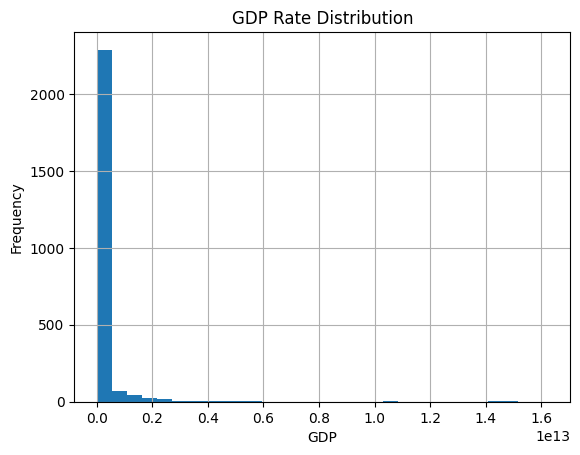

In [17]:
plt.figure()
df['GDP'].hist(bins=30)
plt.title("GDP Rate Distribution")
plt.xlabel("GDP")
plt.ylabel("Frequency")
plt.show()

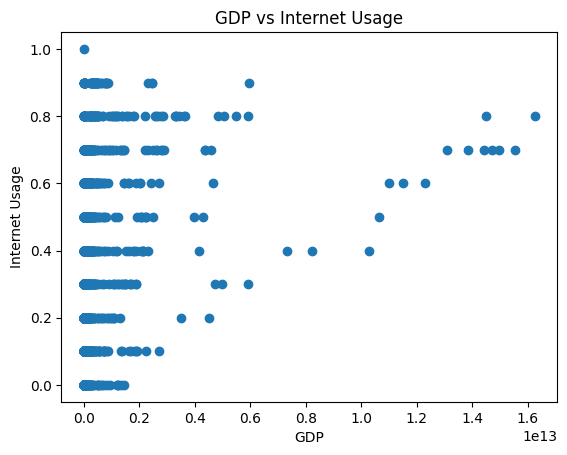

In [18]:
plt.figure()
plt.scatter(df['GDP'], df['Internet Usage'])
plt.title("GDP vs Internet Usage")
plt.xlabel("GDP")
plt.ylabel("Internet Usage")
plt.show()

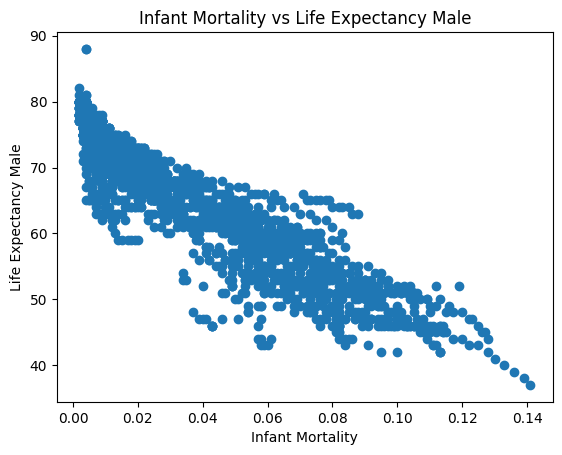

In [19]:
plt.figure()
plt.scatter(df['Infant Mortality Rate'], df['Life Expectancy Male'])
plt.title("Infant Mortality vs Life Expectancy Male")
plt.xlabel("Infant Mortality")
plt.ylabel("Life Expectancy Male")
plt.show()

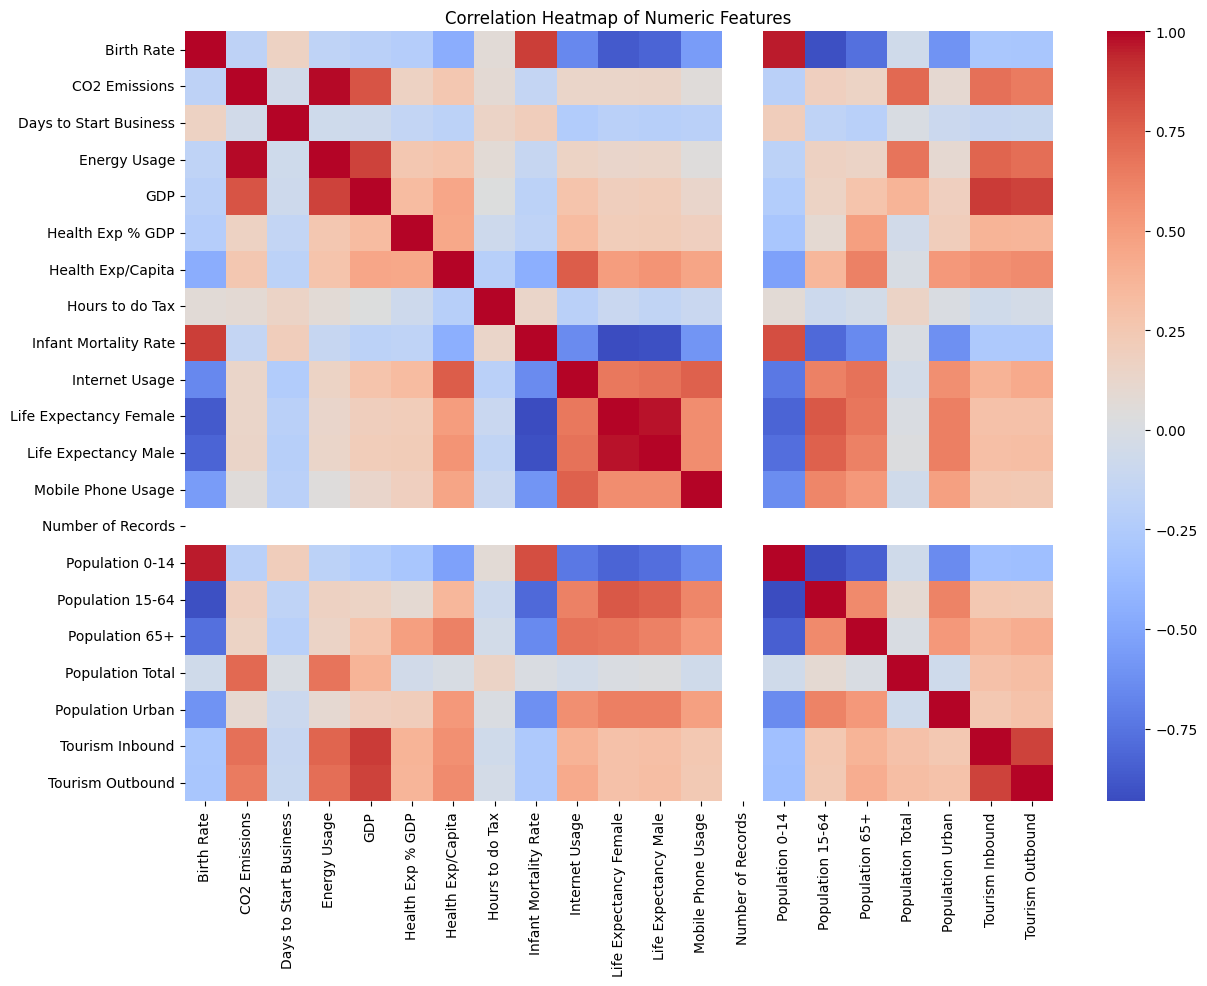

In [20]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

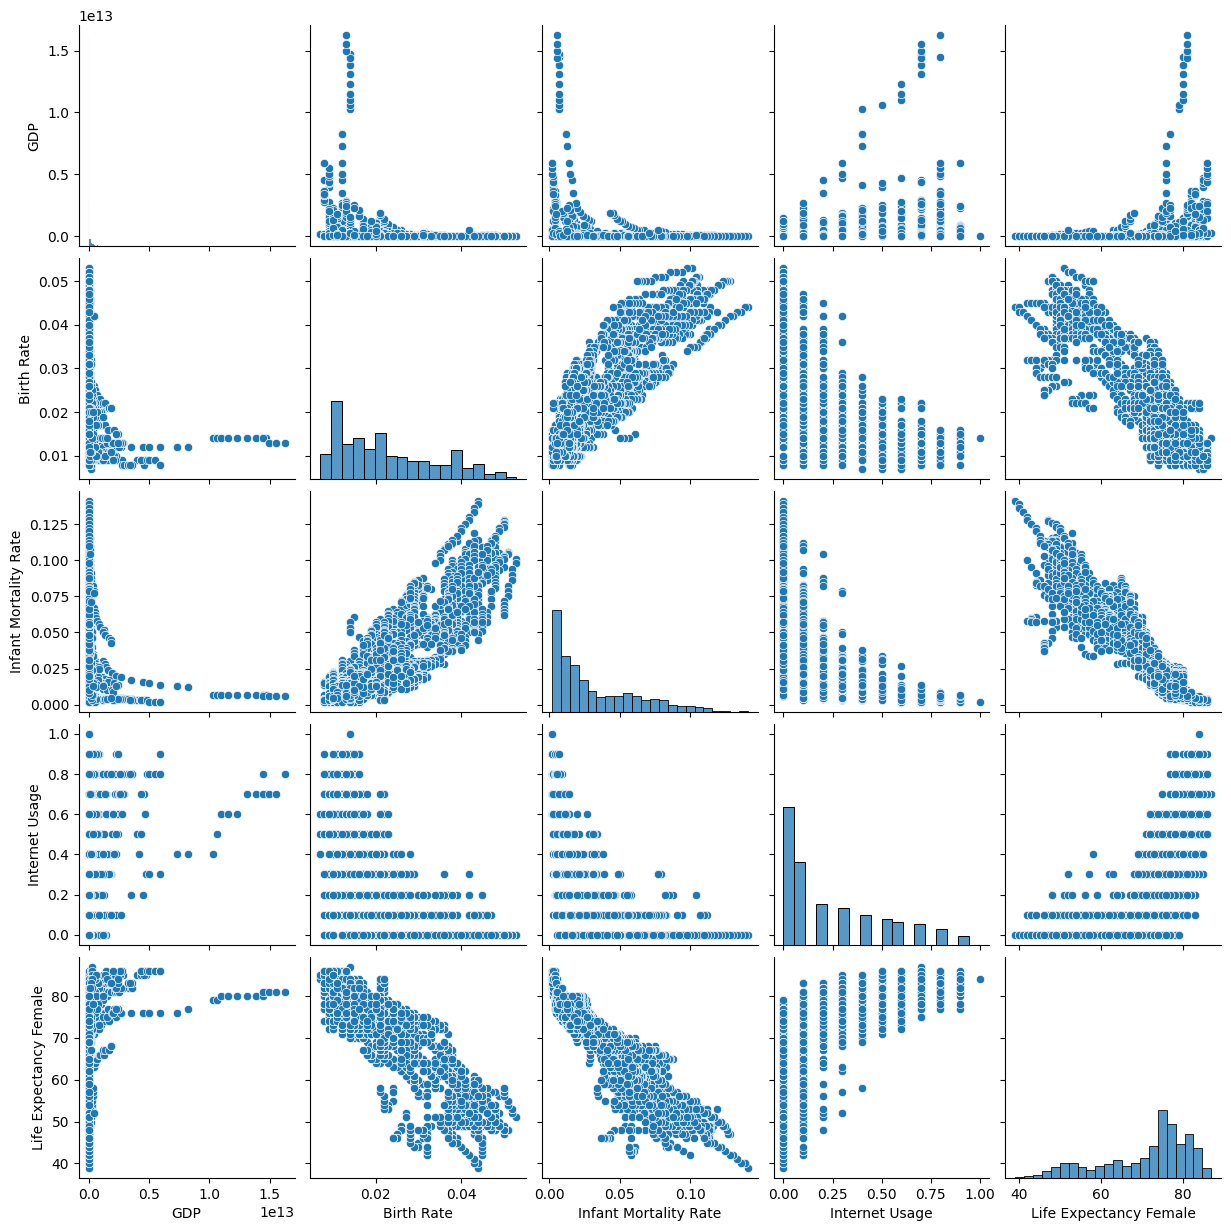

In [21]:
important_cols = ['GDP','Birth Rate','Infant Mortality Rate',
                  'Internet Usage','Life Expectancy Female']

sns.pairplot(df[important_cols])
plt.show()


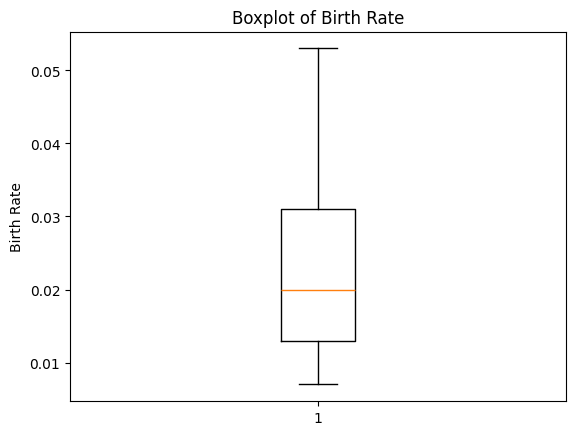

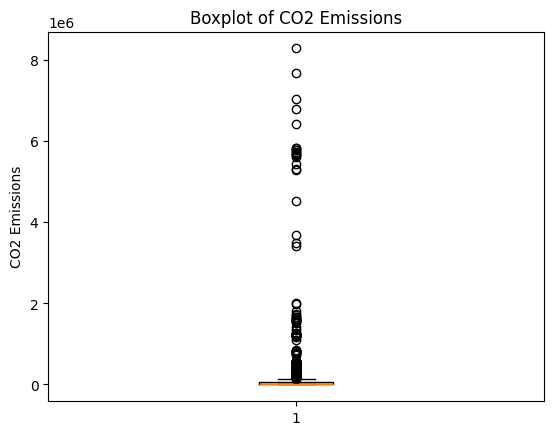

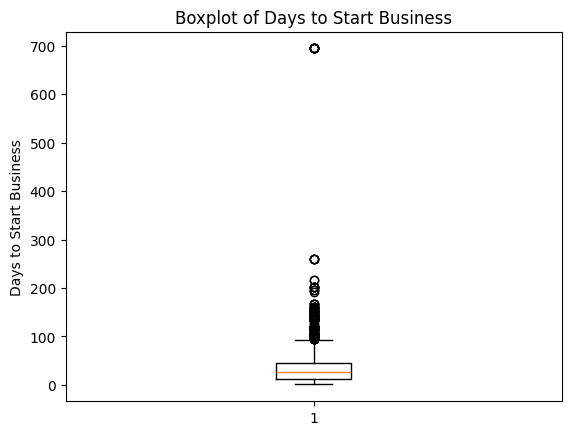

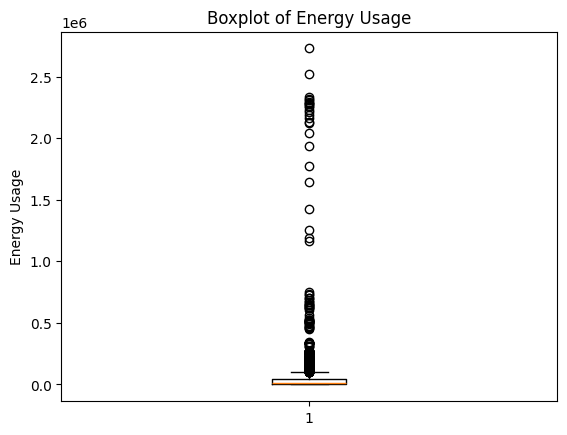

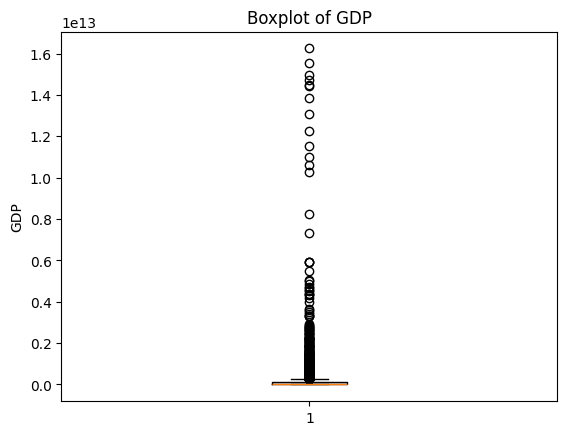

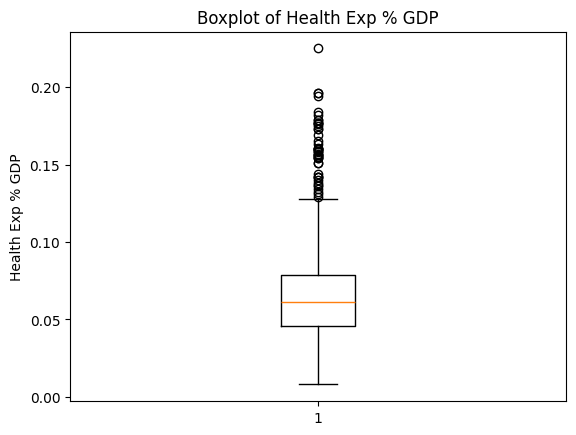

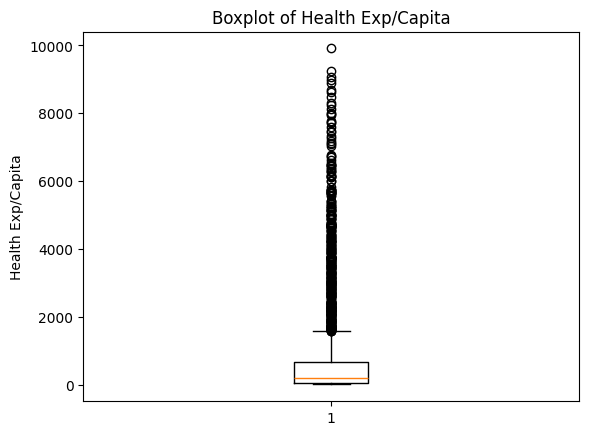

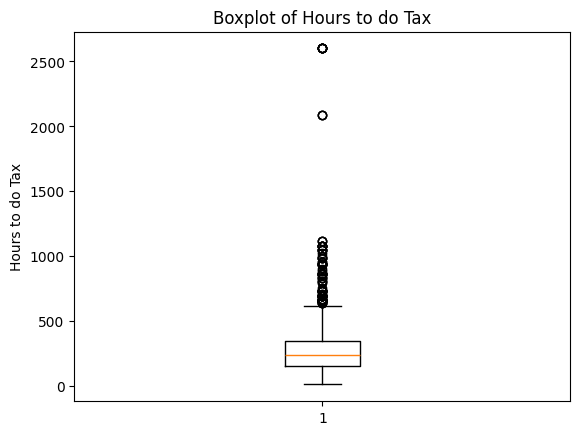

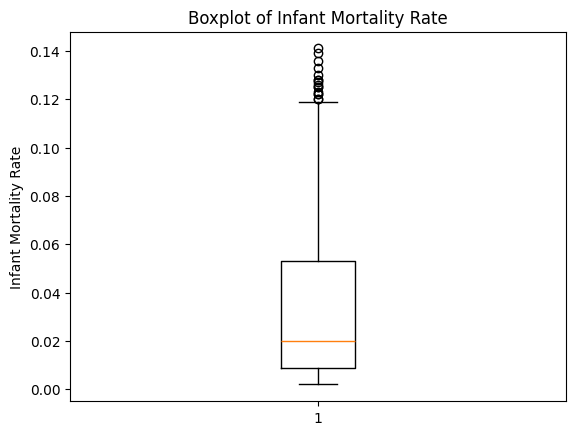

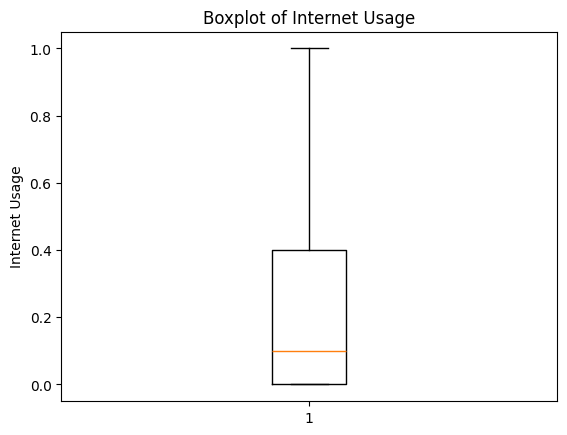

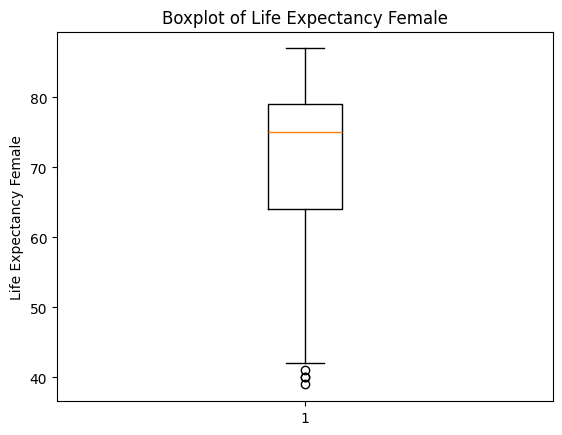

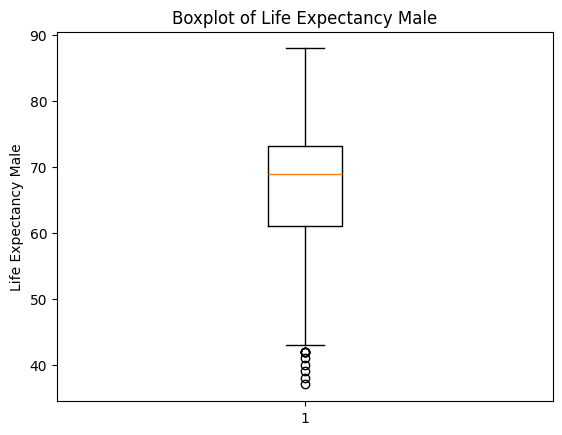

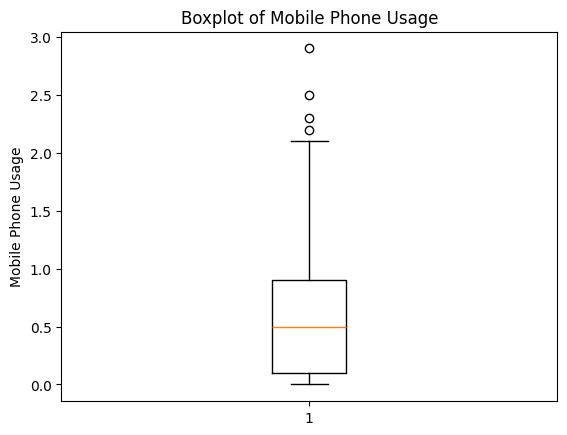

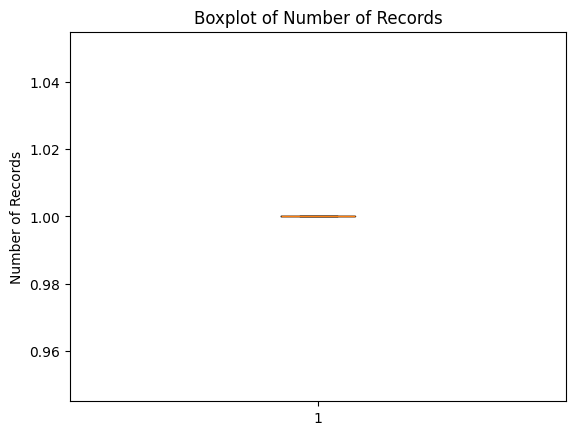

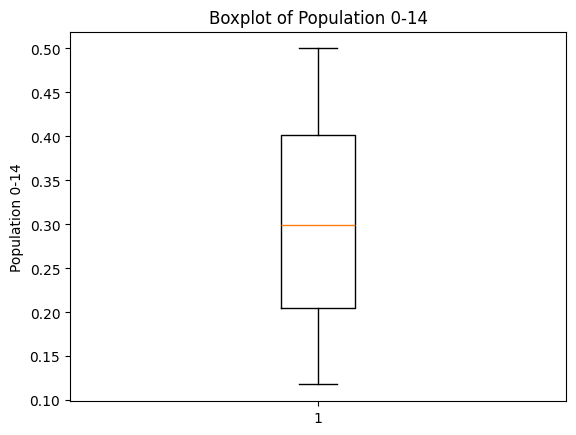

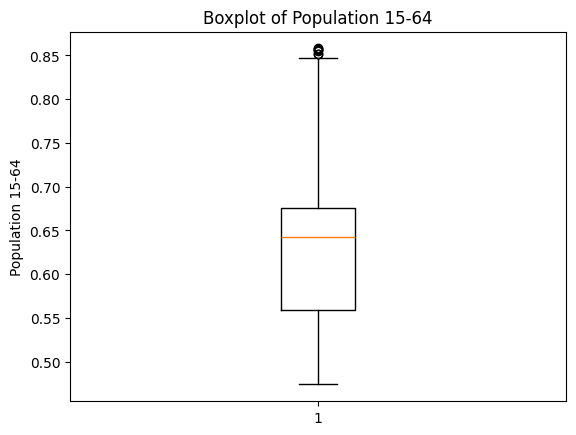

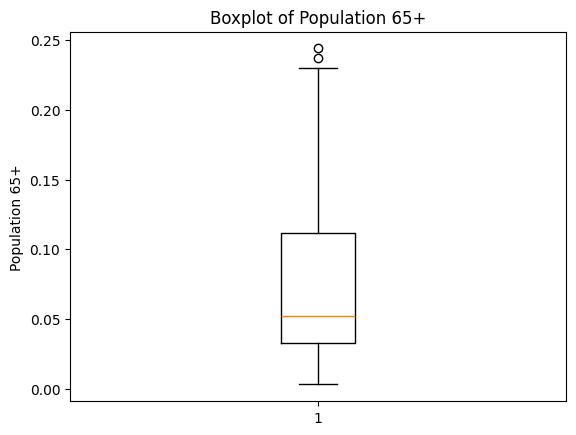

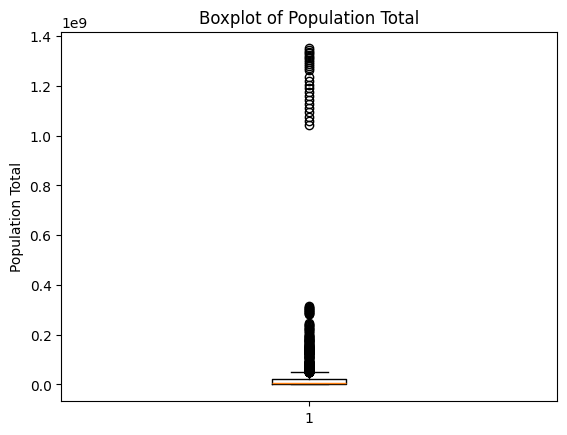

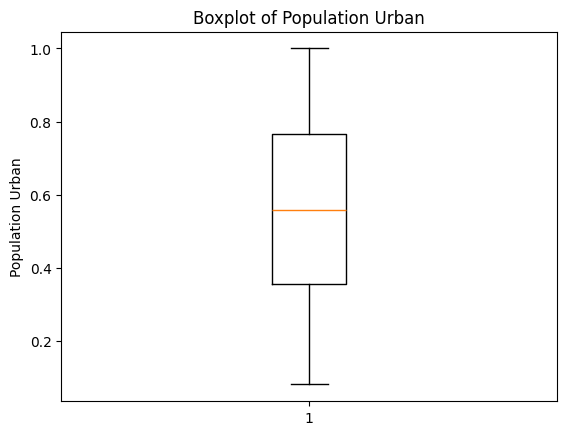

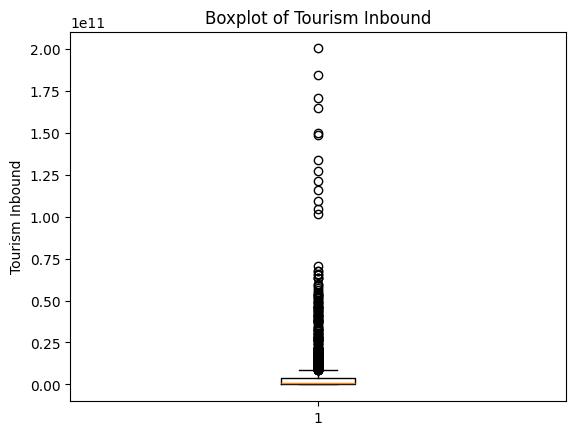

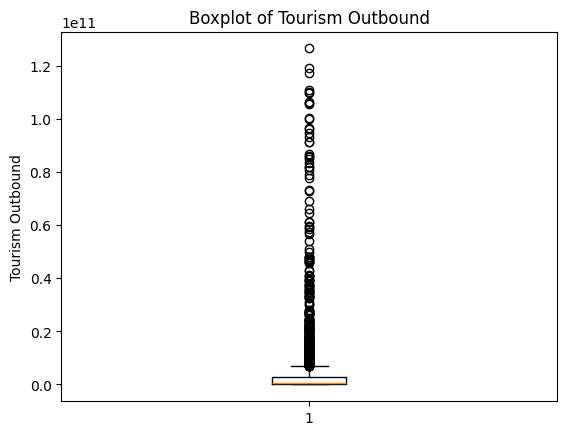

In [22]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [23]:
# Select numerical columns
X = df.select_dtypes(include=np.number).copy()

In [24]:
# Remove columns that do not provide useful clustering information
X = X.drop(columns=['Number of Records'], errors='ignore')


In [25]:

# Handle missing values using median
X = X.fillna(X.median())


In [26]:

# Check missing values
print("Missing values:", X.isnull().sum().sum())


Missing values: 0


In [27]:

# Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2704, 20)


# K-Means — determine optimum clusters

In [28]:
from sklearn.cluster import KMeans

In [29]:

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


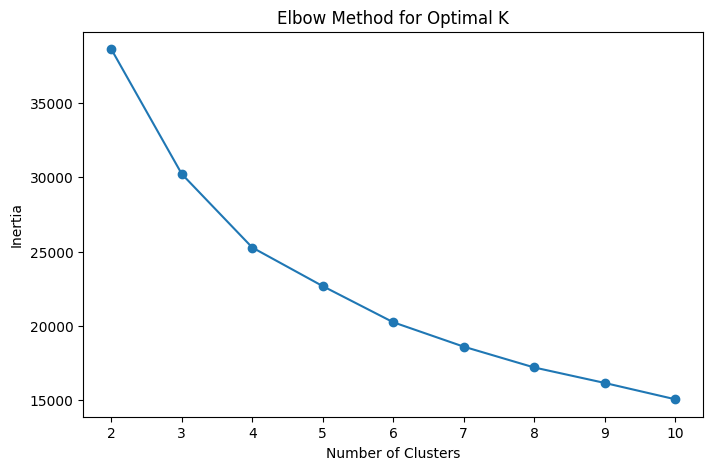

In [30]:

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [31]:
from sklearn.metrics import silhouette_score


In [32]:

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

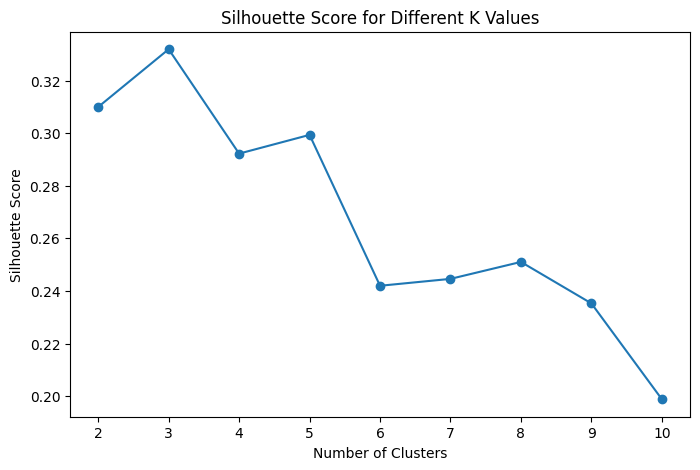

In [33]:

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

In [34]:

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3100
K = 3, Silhouette Score = 0.3319
K = 4, Silhouette Score = 0.2922
K = 5, Silhouette Score = 0.2994
K = 6, Silhouette Score = 0.2420
K = 7, Silhouette Score = 0.2446
K = 8, Silhouette Score = 0.2510
K = 9, Silhouette Score = 0.2353
K = 10, Silhouette Score = 0.1988


In [35]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
1    1622
0    1056
2      26
Name: count, dtype: int64


In [36]:
final_silhouette = silhouette_score(X_scaled, clusters)

print("Final K-Means Evaluation")
print("------------------------")
print("Number of Clusters:", optimal_k)
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", final_silhouette)

Final K-Means Evaluation
------------------------
Number of Clusters: 3
Inertia: 30219.614618348052
Silhouette Score: 0.33193145237115185


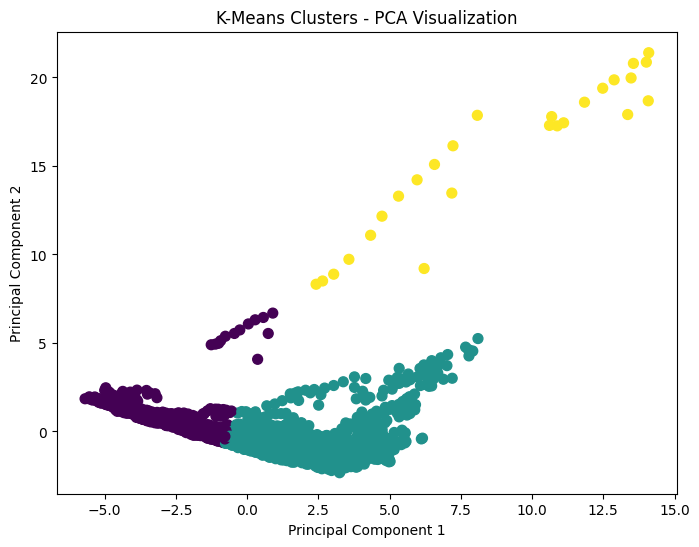

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - PCA Visualization")
plt.show()

# Hierarchical Clustering

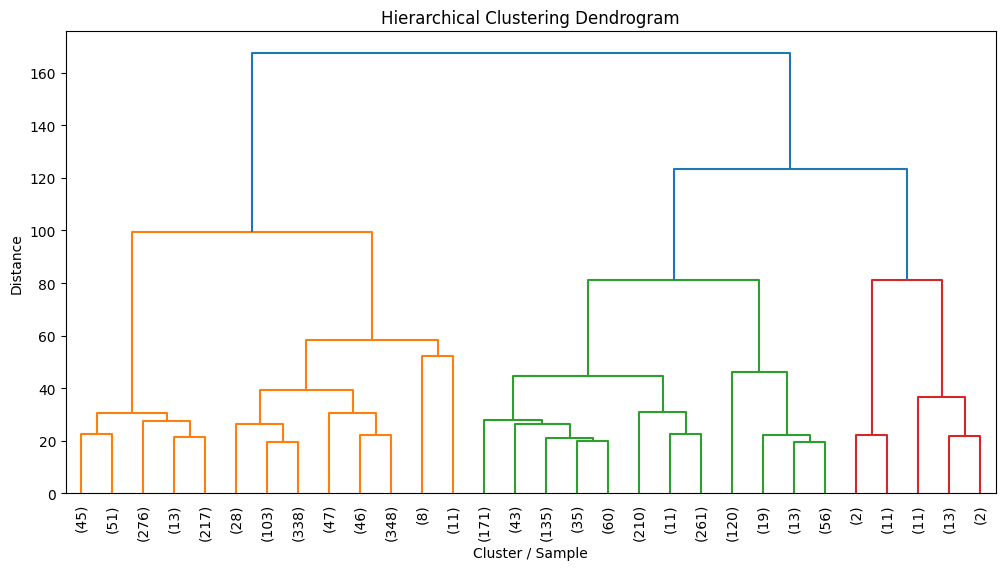

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Create linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Sample")
plt.ylabel("Distance")
plt.show()

In [39]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hierarchical_labels

print(df['Hierarchical_Cluster'].value_counts())

Hierarchical_Cluster
0    1531
2    1134
1      39
Name: count, dtype: int64


In [40]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering")
print("----------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering
----------------------
Number of Clusters: 3
Silhouette Score: 0.2908444481864651


# DBSCAN Clustering

In [41]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    2199
-1     450
 2      13
 3      11
 1      11
 5      10
 4      10
Name: count, dtype: int64


In [42]:
import numpy as np

unique_labels = set(dbscan_labels)

n_clusters = len(
    unique_labels - {-1}
)

n_noise = np.sum(
    dbscan_labels == -1
)

print("Number of DBSCAN clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of DBSCAN clusters: 6
Number of noise points: 450


In [43]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    
    print("DBSCAN Silhouette Score:",
          dbscan_silhouette)
else:
    dbscan_silhouette = np.nan
    print("Silhouette score cannot be calculated.")

DBSCAN Silhouette Score: -0.14168455994760806


In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

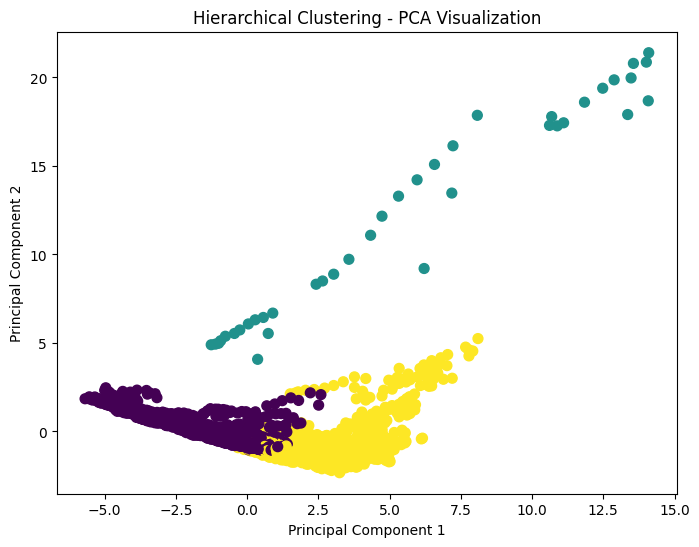

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering - PCA Visualization")
plt.show()

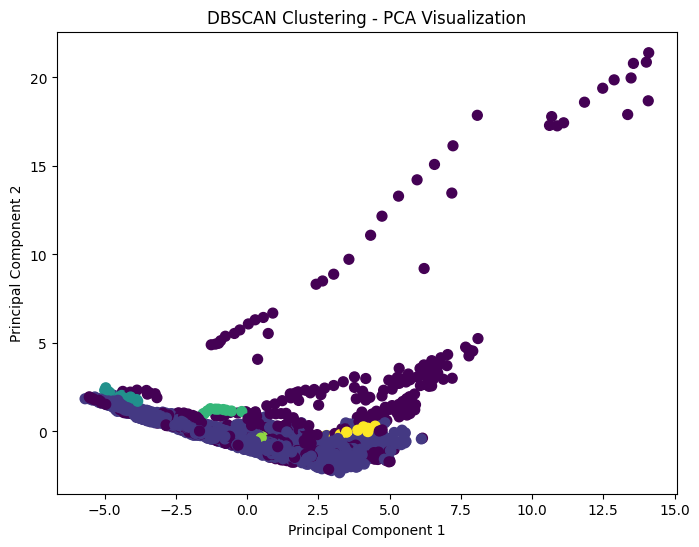

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering - PCA Visualization")
plt.show()

In [47]:
comparison = pd.DataFrame({
    'Model': [
        'K-Means',
        'Hierarchical Clustering',
        'DBSCAN'
    ],
    'Silhouette Score': [
        final_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ]
})

comparison

,Model,Silhouette Score
0,K-Means,0.331931
1,Hierarchical Clustering,0.290844
2,DBSCAN,-0.141685


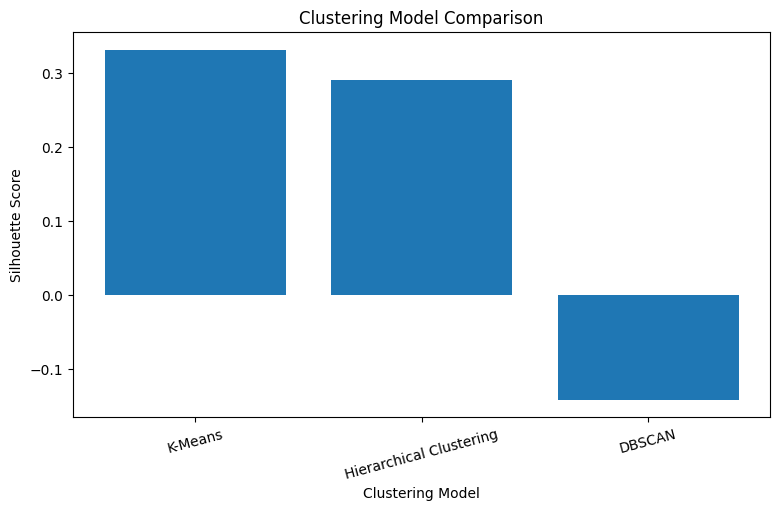

In [48]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison['Model'],
    comparison['Silhouette Score']
)

plt.xlabel("Clustering Model")
plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.xticks(rotation=15)

plt.show()

In [49]:
best_model = comparison.loc[
    comparison['Silhouette Score'].idxmax()
]

print("Best Clustering Model:")
print(best_model['Model'])

print("Best Silhouette Score:")
print(best_model['Silhouette Score'])

Best Clustering Model:
K-Means
Best Silhouette Score:
0.33193145237115185


In [54]:
import joblib

# Save the trained K-Means model
joblib.dump(kmeans, "clustering_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "features.pkl")

print("Files saved successfully!")

Files saved successfully!
